#Linear Model excecution example 

##import modules

In [1]:
import statsmodels.api as sm
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D

##create semi-random data

In [2]:
predictors = np.random.random(1000).reshape(500,2)
# test=predictors
# print(predictors)
# print(test)
#predictors = np.random.random(40)
target = predictors.dot(np.array([0.4,0.6])) + np.random.random(500)
#target = predictors.dot(0.5) + np.random.random(40)


##excecute linear regression 

In [3]:
lmRegModel = sm.OLS(target,predictors)
result = lmRegModel.fit()
y_fitted = result.fittedvalues



##show model results

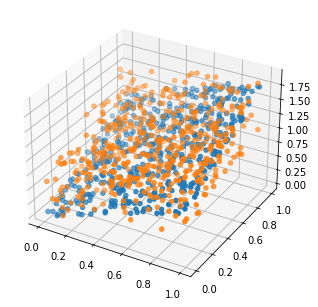

In [4]:
# 此处fig是二维
fig = plt.figure()
 
#将二维转化为三维
axes3d = Axes3D(fig)


axes3d.scatter(predictors[:,0],predictors[:,1],y_fitted)
axes3d.scatter(predictors[:,0],predictors[:,1],target)

# plt.plot(predictors[:],y_fitted,'s')
# plt.plot(predictors[:],target,'ro')
# plt.grid(True)
# plt.xlabel('x-value')
# plt.ylabel('y-value')
# plt.title('test')

In [5]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.886
Model:                            OLS   Adj. R-squared (uncentered):              0.886
Method:                 Least Squares   F-statistic:                              1935.
Date:                Wed, 27 Sep 2023   Prob (F-statistic):                   1.52e-235
Time:                        11:44:56   Log-Likelihood:                         -196.75
No. Observations:                 500   AIC:                                      397.5
Df Residuals:                     498   BIC:                                      405.9
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.8317      0.042     19.847      0.000       0.749       0.914
x2             1.0205      0.043     23.637      0.000       0.936       1.105
==============================================================================
Omnibus:                       37.281   Durbin-Watson:                   1.815
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               14.678
Skew:                          -0.156   Prob(JB):                     0.000650
Kurtosis:                       2.221   Cond. No.                         2.68
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#K nearest neighbor 

##Imports

In [5]:
from sklearn import neighbors, metrics
import numpy as np

##create semi-random data

In [6]:
predictors = np.random.random(1000).reshape(500,2)
#np.random.random()函数可以生成[0.0, 1.)之间的随机浮点数。
target = np.around(predictors.dot(np.array([0.4, 0.6])) + np.random.random(500))

#np.around()函数对输入浮点数执行5舍6入，5做特殊处理（小数点最后一位为5的舍入为与其值最接近的偶数值）。


##excecute k-neigbors classifier

In [7]:
clf = neighbors.KNeighborsClassifier(n_neighbors=10)
knn = clf.fit(predictors,target)

##Model accuracy

In [8]:
knn.score(predictors, target)

0.84

##score the model (make a prediction)

In [9]:
prediction = knn.predict(predictors)

##Confusion matrix

In [10]:
metrics.confusion_matrix(target,prediction)

array([[ 10,  34,   0],
       [  8, 410,   0],
       [  0,  38,   0]], dtype=int64)